In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Ligue1_lens_data import get_team_stats

plt.rcParams['font.family'] = "Malgun Gothic"
plt.rcParams['axes.unicode_minus'] = False


In [2]:
df = pd.read_csv('https://www.football-data.co.uk/mmz4281/2526/F1.csv')
df.sort_index(ascending=False).head(10)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
170,F1,25/01/2026,19:45,Lille,Strasbourg,1,4,A,0,2,...,2.10,1.70,NaN,NaN,2.12,1.75,2.08,1.71,2.25,1.78
169,F1,25/01/2026,16:15,Paris FC,Angers,0,0,D,0,0,...,1.88,1.98,NaN,NaN,1.91,1.98,1.83,1.90,1.96,2.03
168,F1,25/01/2026,16:15,Metz,Lyon,2,5,A,1,4,...,1.98,1.88,NaN,NaN,1.98,1.90,1.94,1.85,2.07,1.90
167,F1,25/01/2026,16:15,Brest,Toulouse,0,2,A,0,2,...,2.00,1.85,NaN,NaN,2.08,1.85,1.98,1.78,2.17,1.83
166,F1,25/01/2026,14:00,Nantes,Nice,1,4,A,1,3,...,1.93,1.93,NaN,NaN,2.00,1.93,1.92,1.85,2.00,1.96
165,F1,24/01/2026,20:05,Marseille,Lens,3,1,H,2,0,...,1.83,2.03,NaN,NaN,1.87,2.03,1.81,1.97,1.87,2.13
164,F1,24/01/2026,18:00,Le Havre,Monaco,0,0,D,0,0,...,1.83,2.03,NaN,NaN,1.90,2.03,1.82,1.96,1.90,2.07
163,F1,24/01/2026,16:00,Rennes,Lorient,0,2,A,0,1,...,2.05,1.80,NaN,NaN,2.05,1.86,1.96,1.82,2.13,1.87
162,F1,23/01/2026,19:00,Auxerre,Paris SG,0,1,A,0,0,...,1.75,2.05,NaN,NaN,1.86,2.05,1.79,1.95,1.86,2.13
161,F1,18/01/2026,19:45,Lyon,Brest,2,1,H,2,0,...,1.83,2.03,NaN,NaN,1.85,2.03,1.80,1.99,1.92,2.05


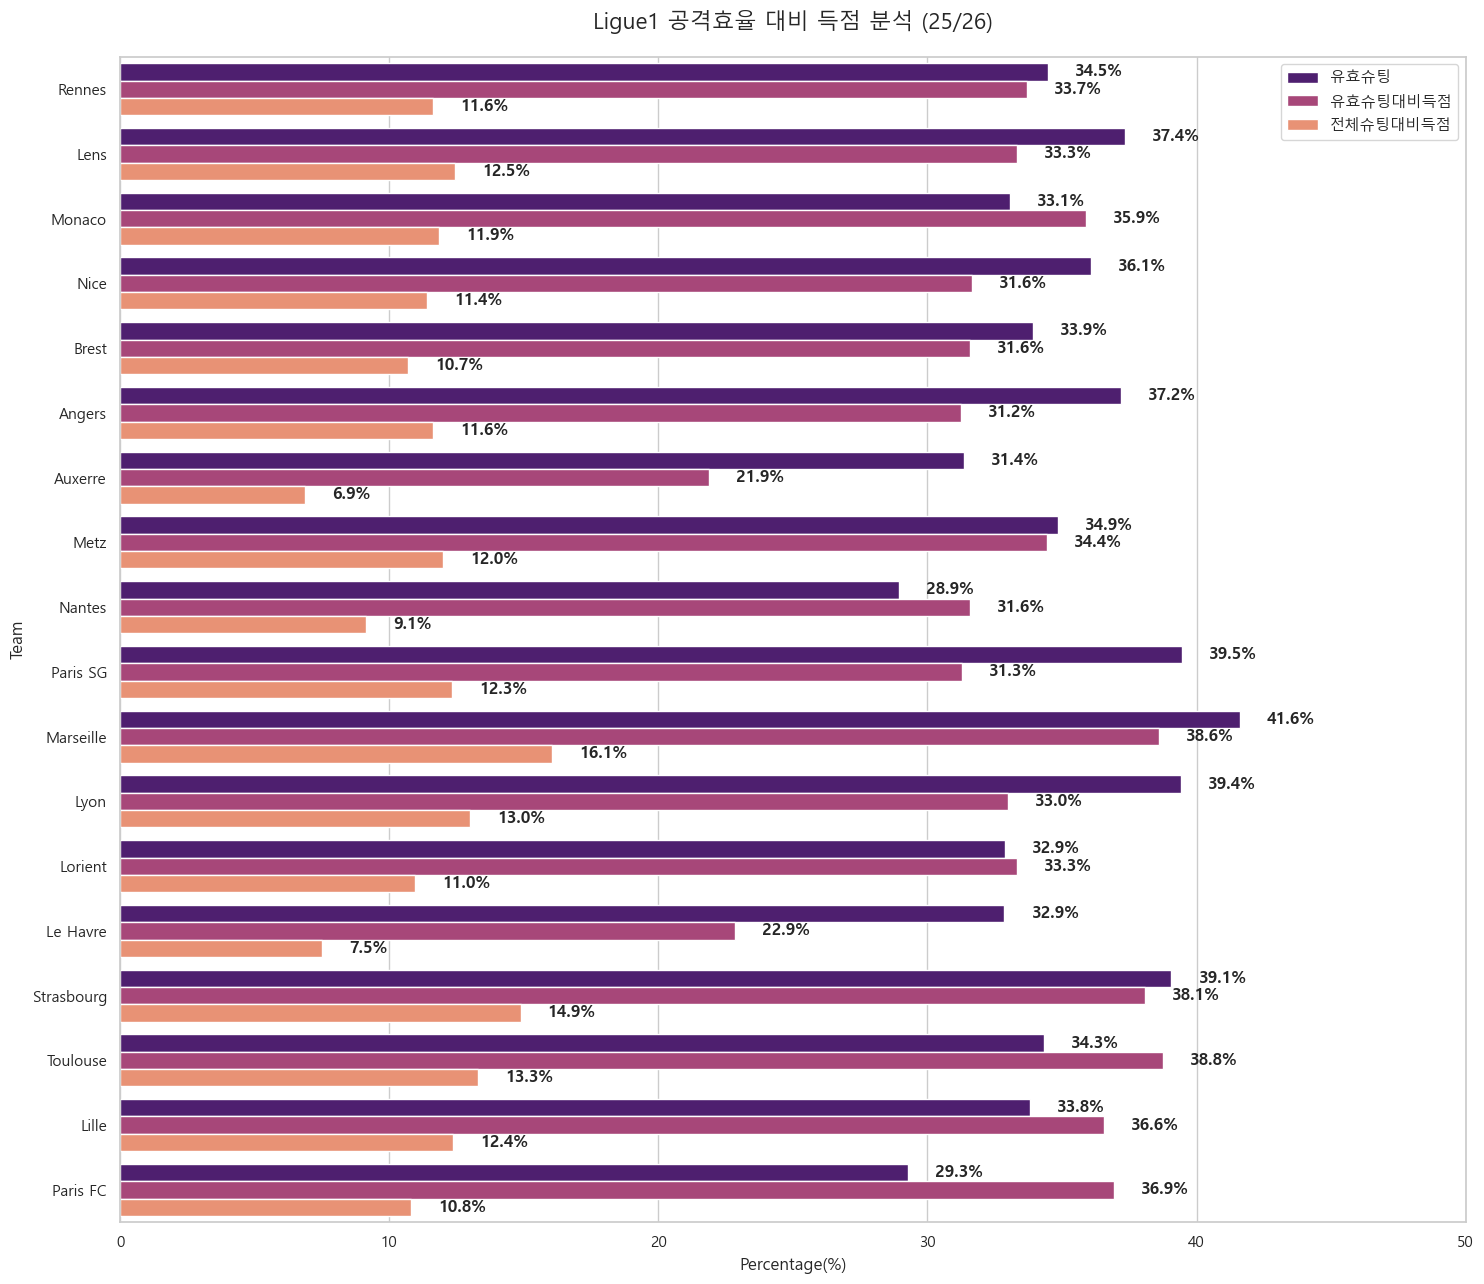

In [5]:
# 1. 데이터에 있는 모든 팀 이름을 중복 없이 가져오기
all_teams = df['HomeTeam'].unique()
results = []

# 원래는 3개의 팀(랑스, psg, metz) 만 쓸려고 만든 df_teams
# df_teams = df[['HomeTeam','AwayTeam','FTHG','FTAG','FTR','HS','AS','HST','AST']] # 홈, 원정, 홈 득점, 원정 득점, 승무패, 홈 슈팅, 원정 슈팅, 홈 유효슈팅, 원정 유효슈팅

# 2. for문으로 모든 팀을 하나씩 분석
for team in all_teams:
  team_list = get_team_stats(df, team)
  results.extend(team_list)

df_compare = pd.DataFrame(results)
# 공격효율 관련 지표만 필터링
offense_metrics = ['유효슈팅', '유효슈팅대비득점', '전체슈팅대비득점', '코너킥대비득점']
df_offense = df_compare[df_compare['Type'] == 'Attack']

# 그래프 스타일 설정
sns.set_theme(style='whitegrid')
plt.figure(figsize=(15,13))
# 한글 설정
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
# 3. 가로형 바 그래프 (18개 팀 전체)
ax = sns.barplot(
  data=df_offense, 
  x='Value', 
  y='Team', 
  hue='Metric', # 색상을 구분할 기준
  palette='magma', 
  legend=True # 범례 사용할시 True로
  )

# 수치 표시
for p in ax.patches: # p는 각 막대(객체)를 의미
  # width : 막대의 가로 길이(Value값)를 가져옴
  width = p.get_width()
  if width > 0: # 0보다 큰 값일 때만 텍스트를 그립니다
    # plt.text(x좌표, y좌표, 표시할 내용, 옵션)
    plt.text(
      width + 1, # 막대 끝에서 1만큼 오른쪽 여백
      p.get_y() + p.get_height()/2, # 막대의 세로 위치(y)에서 높이의 절반을 더해 '중앙에 맞춤
      f'{width:.1f}%', # width 값을 소수점 첫째 자리까지 문자열로 포맷팅
      va='center',  # 수직 정렬을 중앙으로 설정
      fontweight='bold' # 글씨는 굵게
    )


# 타이틀을 포함 마무리 
plt.title("Ligue1 공격효율 대비 득점 분석 (25/26)",fontsize=16, pad=20)
plt.xlabel('Percentage(%)')
plt.xlim(0, 50) # 수치 표시 공간 확보
plt.tight_layout()

plt.legend()
plt.show()


C:\Users\ojy05\AppData\Local\Temp\ipykernel_13348\3364690866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


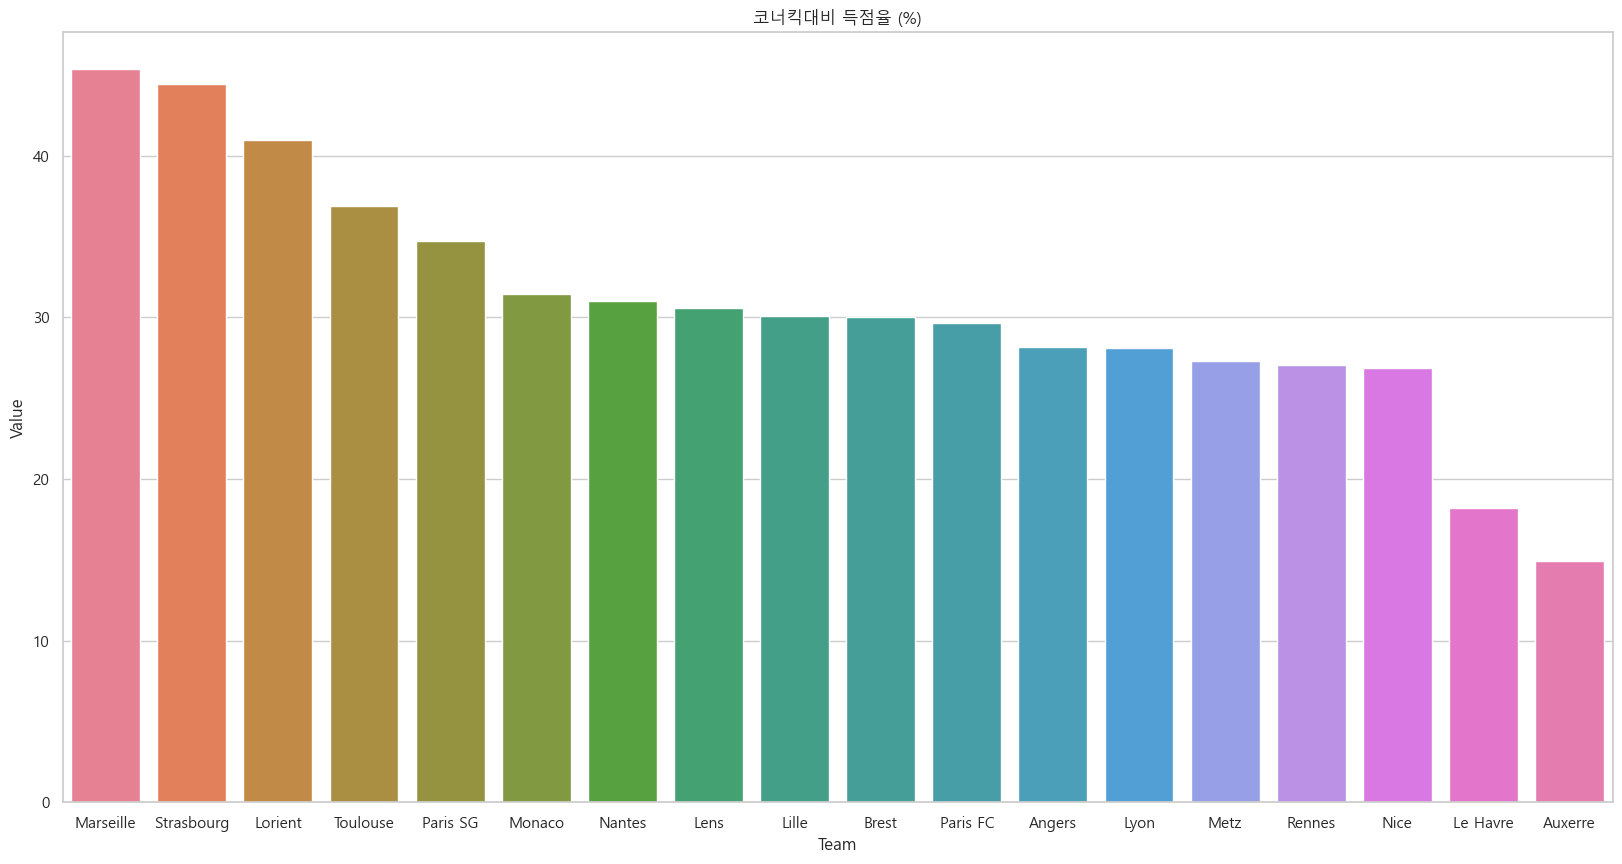

In [14]:
df_corner = df_compare[df_compare['Metric'] == '코너킥대비득점'].sort_values('Value', ascending=False)
plt.figure(figsize=(20,10))
sns.barplot(
  data=df_corner,
  x='Team', 
  y='Value', 
  palette='husl'
)
plt.title('코너킥대비 득점율 (%)')
plt.show()

C:\Users\ojy05\AppData\Local\Temp\ipykernel_13348\4044730488.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


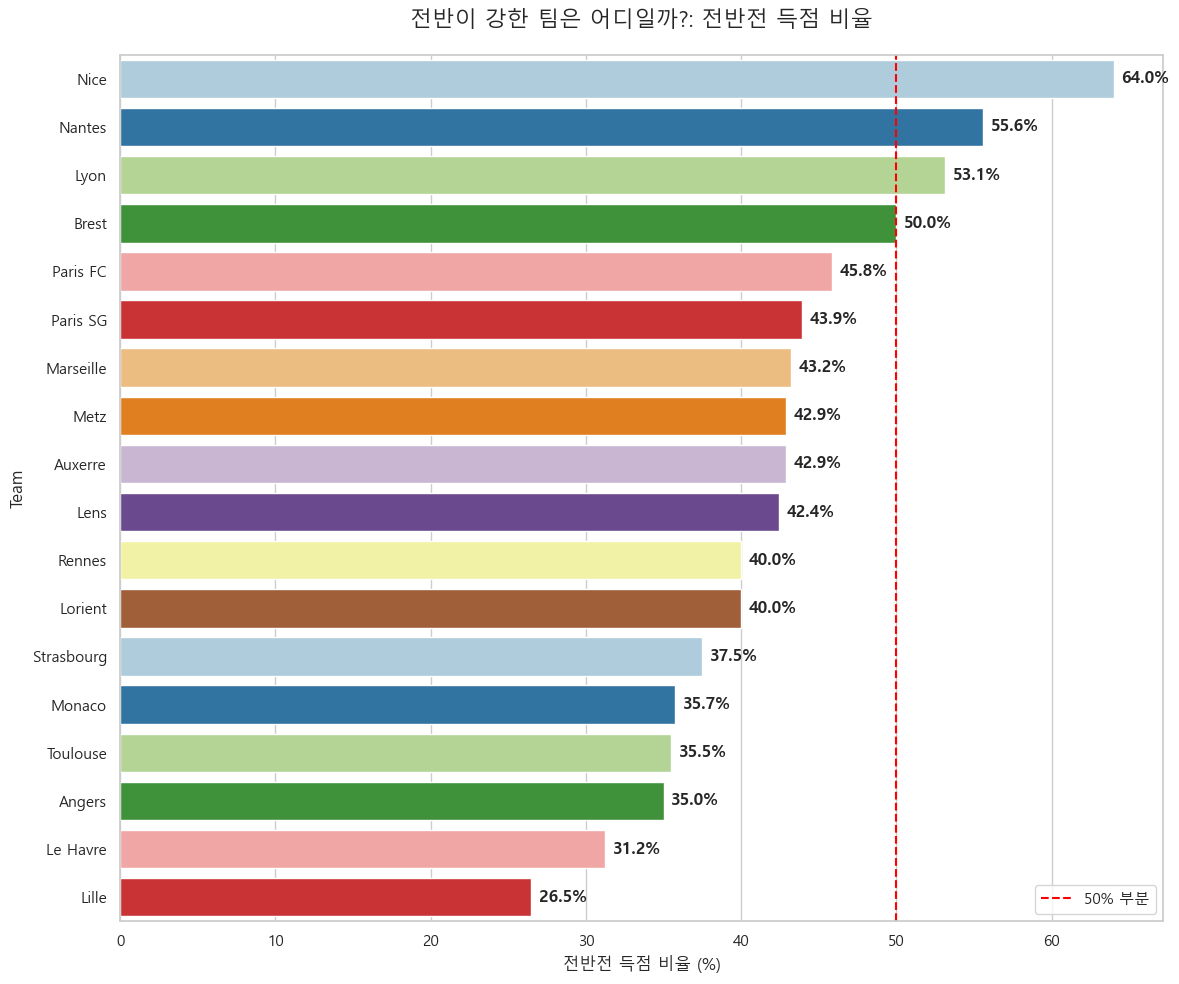

In [13]:
# 전반전 비중 지표만 필터링 및 정렬
df_half = df_compare[df_compare['Metric'] == '전반전득점'].sort_values('Value', ascending=False)

plt.figure(figsize=(12,10))
# 비중이 50% 넘는 팀은 눈에 띄게 색상을 다르게 줄 수도 있습니다.
colors = ['#FFCC00' if x == 'Lens' else 'skyblue' for x in df_half['Team']]

ax2 = sns.barplot(
  data = df_half,
  x='Value',
  y='Team',
  palette='Paired',
  legend=True
)

# 50% 가이드라인 (전반/후반이 반반인 기준선)
plt.axvline(50, color='red', linestyle='--', label='50% 부분')

# 수치 표시
for p in ax2.patches:
    width = p.get_width()
    ax2.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontweight='bold')

plt.title("전반이 강한 팀은 어디일까?: 전반전 득점 비율", fontsize=16, pad=20)
plt.xlabel("전반전 득점 비율 (%)")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\ojy05\AppData\Local\Temp\ipykernel_13348\536142739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


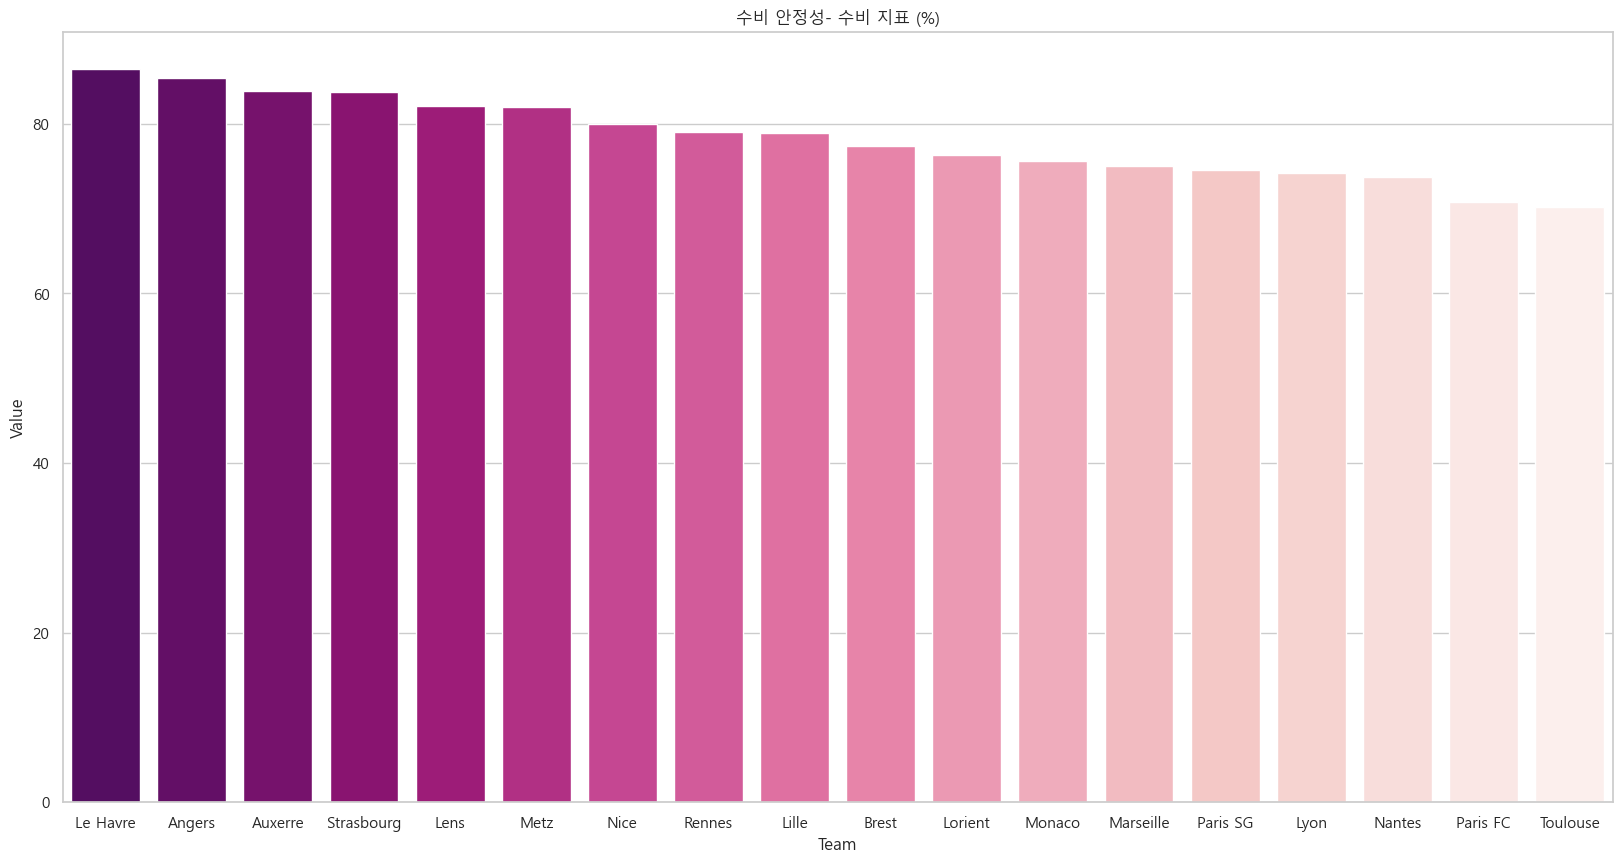

In [ ]:
# 수비 안정성 - 수비 지표
df_defense = df_compare[df_compare['Metric'] == '수비지표'].sort_values('Value', ascending=False)
plt.figure(figsize=(20,10))
sns.barplot(
  data=df_defense,
  x='Team',
  y='Value',
  palette='RdPu_r'
)
plt.title('수비 안정성- 수비 지표 (%)')
plt.show()

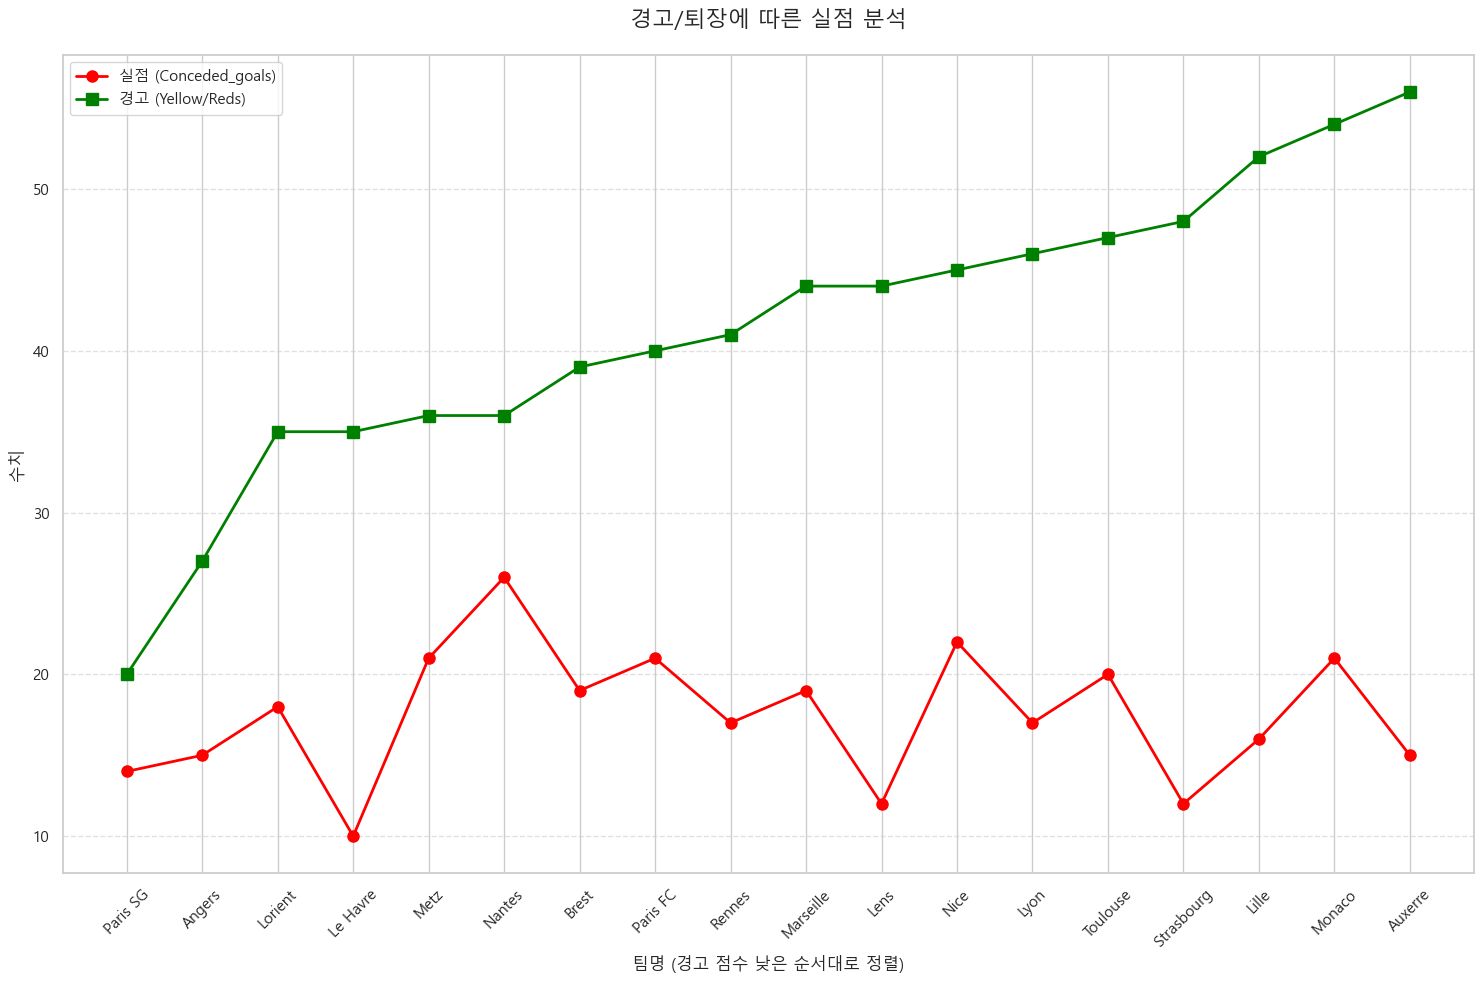

In [33]:
# 경고/퇴장 간의 실점 상관관계
# 1. 데이터를 경고 점수 기준으로 정렬
df_pivot = df_compare.pivot(index='Team', columns='Metric', values='Value').reset_index()
df_line = df_pivot.sort_values('경고 점수').reset_index(drop=True)

plt.figure(figsize=(15,10))

# 2. 꺾은선 그래프 그리기
# 실점 흐름
plt.plot(df_line['Team'], df_line['실점'], marker='o', color='red', label='실점 (Conceded_goals)', linewidth=2, markersize=8)
# 경고 점수 흐름
plt.plot(df_line['Team'], df_line['경고 점수'], marker='s', color='green', label='경고 (Yellow/Reds)', linewidth=2, markersize=8)

plt.xticks(rotation=45)
plt.title('경고/퇴장에 따른 실점 분석', fontsize=16, pad=20)
plt.xlabel('팀명 (경고 점수 낮은 순서대로 정렬)', fontsize=12)
plt.ylabel('수치', fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


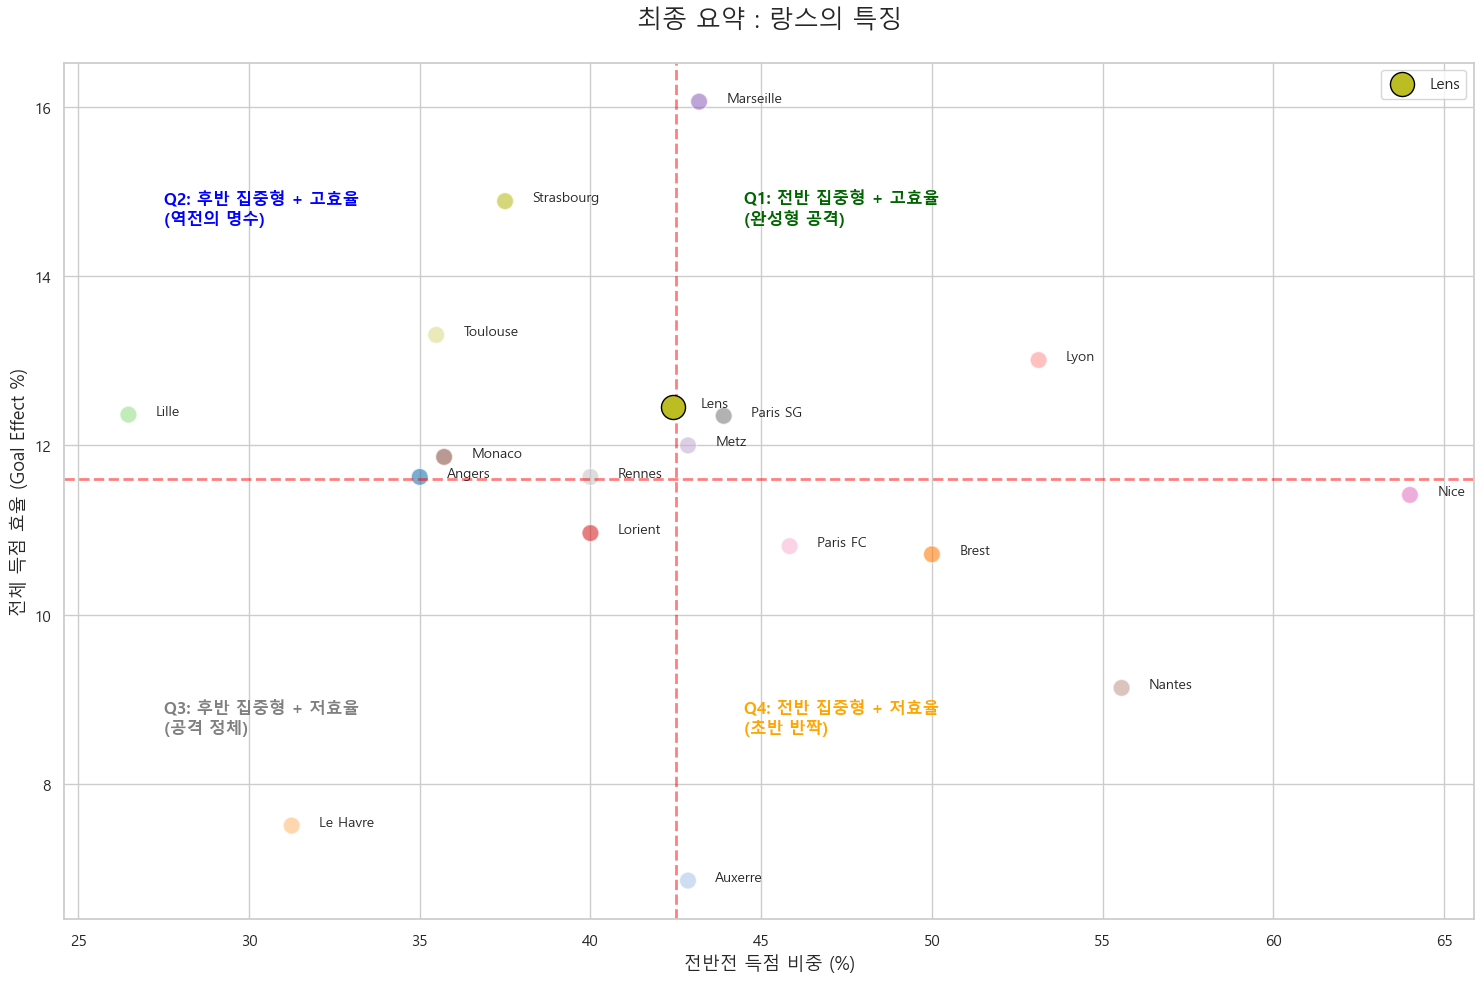

In [35]:
# 랑스의 특징을 산점도로 표시
plt.figure(figsize=(15,10))
# 1. 평균값 계산 (4분할 기준선)
avg_half = df_pivot['전반전득점'].mean()
avg_eff = df_pivot['전체슈팅대비득점'].mean()

# 2. 전체 팀 산점도 표시
sns.scatterplot(
  data= df_pivot,
  x='전반전득점',
  y='전체슈팅대비득점',
  s=150,
  palette='tab20',
  hue='Team',
  alpha=0.6,
  legend=False
)

# 3. 랑스 강조
lens = df_pivot[df_pivot['Team'] == 'Lens']
plt.scatter(lens['전반전득점'], lens['전체슈팅대비득점'], color='#bcbd22', s=300, edgecolors='black', label='Lens', zorder=10)

# 4. 18개 전 팀 이름 표시
for i in range(df_pivot.shape[0]):
  plt.text(
  df_pivot['전반전득점'][i] + 0.8,
  df_pivot['전체슈팅대비득점'][i],
  df_pivot['Team'][i],
  fontsize=10
  )
# 5. 4분할 가이드라인 그리기
plt.axvline(avg_half, color='red', linestyle='--', alpha=0.5, linewidth=2) # 세로 평균선
plt.axhline(avg_eff,  color='red', linestyle='--', alpha=0.5, linewidth=2) # 가로 평균선

# 6. 각 사분면의 특징 설명 추가
plt.text(avg_half + 2, avg_eff + 3, 'Q1: 전반 집중형 + 고효율\n(완성형 공격)', color='darkgreen', fontsize=12, fontweight='bold')
plt.text(avg_half - 15, avg_eff + 3, 'Q2: 후반 집중형 + 고효율\n(역전의 명수)', color='blue', fontsize=12, fontweight='bold')
plt.text(avg_half - 15, avg_eff - 3, 'Q3: 후반 집중형 + 저효율\n(공격 정체)', color='grey', fontsize=12, fontweight='bold')
plt.text(avg_half + 2, avg_eff - 3, 'Q4: 전반 집중형 + 저효율\n(초반 반짝)', color='orange', fontsize=12, fontweight='bold')


plt.title('최종 요약 : 랑스의 특징', fontsize=18, pad=25)
plt.xlabel('전반전 득점 비중 (%)', fontsize=13)
plt.ylabel('전체 득점 효율 (Goal Effect %)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()